In [ ]:
# See here https://developers.llamaindex.ai/python/examples/evaluation/questiongeneration/

In [45]:
import nest_asyncio
nest_asyncio.apply()


In [46]:
# 1.0 Call libraries
# https://developers.llamaindex.ai/python/framework-api-reference/evaluation/dataset_generation/#llama_index.core.evaluation.DatasetGenerator
from llama_index.llms.ollama import Ollama
from llama_index.embeddings.ollama import OllamaEmbedding
from llama_index.core import Settings
# 1.1
from llama_index.core.evaluation import DatasetGenerator, RelevancyEvaluator
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, Response

In [47]:
# 1.1 Configure the llm
llm = Ollama(model="llama3.2:3b-instruct-q8_0",
             request_timeout=3600.0,
             temperature = 0.9
            )

Settings.llm = llm

# 1.2 Global Embedding Model
Settings.embed_model = OllamaEmbedding(
                                       model_name="nomic-embed-text"
                                      )

In [48]:
import logging
import sys
import pandas as pd

logging.basicConfig(stream=sys.stdout, level=logging.INFO)
logging.getLogger().addHandler(logging.StreamHandler(stream=sys.stdout))

In [49]:
from llama_index.core.evaluation import DatasetGenerator, RelevancyEvaluator
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, Response

In [51]:
path = "/home/ashok/Documents/scorders/txt_files/"
reader = SimpleDirectoryReader(path)
documents = reader.load_data()

This will print the word count for each document. You can also access other attributes like doc.doc_id or doc.metadata as needed. According to SimpleDirectoryReader documentation, documents is a list of Document objects, each with a .text field.

In [61]:
# No of words per document
#   wc -w filename.txt
for doc in documents:
    print(len(doc.text.split()))

1026


In [53]:
# 
data_generator = DatasetGenerator.from_documents(documents,
                                                  llm = llm,
                                                  num_questions_per_chunk=5,  # Default is 10
                                                  show_progress=True 
                                                 )

Applying transformations: 100%|███████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 151.62it/s]
/home/ashok/langchain/lib/python3.13/site-packages/llama_index/core/evaluation/dataset_generation.py:201: DeprecationWarning: Call to deprecated class DatasetGenerator. (Deprecated in favor of `RagDatasetGenerator` which should be used instead.)
  return cls(


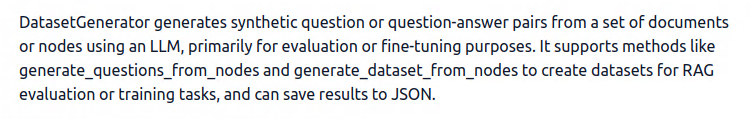

In [54]:
%%time
# num_questions_per_chunk=5,
# show_progress=True,
eval_questions = data_generator.generate_questions_from_nodes()

INFO:httpx:HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"


  0%|                                                                                                                          | 0/3 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


 33%|██████████████████████████████████████                                                                            | 1/3 [00:18<00:36, 18.17s/it]

INFO:httpx:HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


 67%|████████████████████████████████████████████████████████████████████████████                                      | 2/3 [00:36<00:18, 18.02s/it]

INFO:httpx:HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:50<00:00, 16.87s/it]

CPU times: user 50.7 ms, sys: 3.09 ms, total: 53.8 ms
Wall time: 50.7 s



/home/ashok/langchain/lib/python3.13/site-packages/llama_index/core/evaluation/dataset_generation.py:297: DeprecationWarning: Call to deprecated class QueryResponseDataset. (Deprecated in favor of `LabelledRagDataset` which should be used instead.)
  return QueryResponseDataset(queries=queries, responses=responses_dict)


In [55]:
eval_questions

['Here are five questions based on the context information:',
 'What is the date of decision mentioned in the case?',
 'Who is the Respondent through whom the Land Acquisition Collector (North) has been represented?',
 'What is the prayer sought by the Petitioners under Article 226 of the Constitution of India?',
 'In what year was Ms. Sundari Agarwal, the mother of Petitioner Nos. 1 and 2, declared dead, and whose property was inherited by them?',
 'What order dated 21st October, 2003, vested in which authority the land in Khasra Nos. 79/20, 79/21, 79/22?',
 'Here are five questions based on the provided context information:',
 'What was the result of the appeal filed by the Petitioners against the order dated 21st October, 2003, passed by the Revenue Assistant?',
 'Who inherited the property of Ms. Kanta Nagpal after her death in 2000, and what were the resulting khasras vested in the Gaon Sabha?',
 'What is the nature of the dispute between the Petitioners and the Land Acquisition C

In [56]:
# 1.1 Configure the llm
llm = Ollama(model="llama3.2:latest",
             request_timeout=3600.0,
             temperature = 0.9
            )


In [57]:
evaluator_llm = RelevancyEvaluator(llm=llm)

In [58]:
# create vector index
vector_index = VectorStoreIndex.from_documents(documents)

INFO:httpx:HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"


In [59]:
# define jupyter display function
def display_eval_df(query: str, response: Response, eval_result: str) -> None:
    eval_df = pd.DataFrame(
        {
            "Query": query,
            "Response": str(response),
            "Source": (
                response.source_nodes[0].node.get_content()[:1000] + "..."
            ),
            "Evaluation Result": eval_result,
        },
        index=[0],
    )
    eval_df = eval_df.style.set_properties(
        **{
            "inline-size": "600px",
            "overflow-wrap": "break-word",
        },
        subset=["Response", "Source"],
    )
    display(eval_df)

In [63]:
query_engine = vector_index.as_query_engine()

In [64]:
response_vector = query_engine.query(eval_questions[1])
eval_result = evaluator_llm.evaluate_response(
                                               query=eval_questions[1],
                                               response=response_vector
                                              )

INFO:httpx:HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/embed "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/chat "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 OK"
HTTP Request: POST http://localhost:11434/api/show "HTTP/1.1 200 

In [70]:
# See here:
# https://developers.llamaindex.ai/python/framework/module_guides/evaluating/usage_pattern/

df = pd.DataFrame([eval_result.__dict__])
print(df.T)  # Transpose for vertical display

                                                                 0
query            What is the date of decision mentioned in the ...
contexts         [$~34\n\nIN THE HIGH COURT OF DELHI AT NEW DEL...
response         The date of decision mentioned in the case is ...
passing                                                      False
feedback                                                        NO
score                                                          0.0
pairwise_source                                               None
invalid_result                                               False
invalid_reason                                                None


In [71]:
import pandas as pd

# Convert EvaluationResult to a dictionary and transpose for readability
df = pd.DataFrame([eval_result.__dict__]).T
df.columns = ['Value']  # Rename the value column
df.index.name = 'Field'  # Name the index

# Optional: pretty print with styling in Jupyter
from IPython.display import display
display(df.style.set_properties(**('background-color': '#f9f9f9', 'border': '1px solid #ccc')))


SyntaxError: invalid syntax (2077058248.py, line 10)

In [73]:
display(df.style.set_properties(**{'background-color': '#f9f9f9', 'border': '1px solid #ccc'}))


INFO:matplotlib.font_manager:Failed to extract font properties from /usr/share/fonts/truetype/noto/NotoColorEmoji.ttf: Can not load face (unknown file format; error code 0x2)
Failed to extract font properties from /usr/share/fonts/truetype/noto/NotoColorEmoji.ttf: Can not load face (unknown file format; error code 0x2)
Failed to extract font properties from /usr/share/fonts/truetype/noto/NotoColorEmoji.ttf: Can not load face (unknown file format; error code 0x2)
Failed to extract font properties from /usr/share/fonts/truetype/noto/NotoColorEmoji.ttf: Can not load face (unknown file format; error code 0x2)
Failed to extract font properties from /usr/share/fonts/truetype/noto/NotoColorEmoji.ttf: Can not load face (unknown file format; error code 0x2)
INFO:matplotlib.font_manager:Failed to extract font properties from /usr/share/fonts/truetype/unifont/unifont_sample.ttf: Could not set the fontsize (invalid pixel size; error code 0x17)
Failed to extract font properties from /usr/share/font